#Učitavanje biblioteka i skupa podataka

U ovom dijelu projekta učitane su biblioteke Pandas, NumPy i Matplotlib koje se koriste za obradu, analizu i vizuelizaciju podataka. Nakon toga učitan je CSV fajl koji sadrži podatke o pametnoj poljoprivredi i prinosima usjeva. Funkcija head() korišćena je za prikaz prvih nekoliko redova kako bi se dobio osnovni pregled strukture skupa podataka.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Smart_Farming_Crop_Yield_2024.csv")

df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


#Analiza strukture i kvaliteta skupa podataka

U ovom dijelu izvršena je osnovna analiza skupa podataka korišćenjem funkcija shape(), info(), describe() i isnull().sum(). Prikazane su dimenzije skupa podataka, tipovi atributa, osnovne statističke karakteristike, kao i prisustvo nedostajućih vrijednosti. Cilj ove analize je bolje razumijevanje podataka i priprema za dalju obradu i obuku modela mašinskog učenja.

In [2]:
df.shape

(500, 22)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

In [4]:
df.describe()

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,yield_kg_per_hectare,latitude,longitude,NDVI_index
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.03014,26.586980,119.496000,4032.92694,22.442473,80.392248,0.602060
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.69167,13.202429,16.798046,1174.43304,7.283492,5.910664,0.175402
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.01000,5.050000,90.000000,2023.56000,10.004243,70.020021,0.300000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.66750,14.945000,105.750000,2994.82000,16.263202,75.374713,0.447500
50%,25.855000,6.530000,24.655000,191.545000,65.685000,6.99500,25.980000,119.000000,4071.69000,21.981743,80.650284,0.610000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.47000,38.005000,134.000000,5062.11000,28.528948,85.654629,0.750000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.00000,49.940000,150.000000,5998.29000,34.981531,89.991901,0.900000


In [5]:
df.isnull().sum()

,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,0
irrigation_type,150


#Vizuelizacija podataka

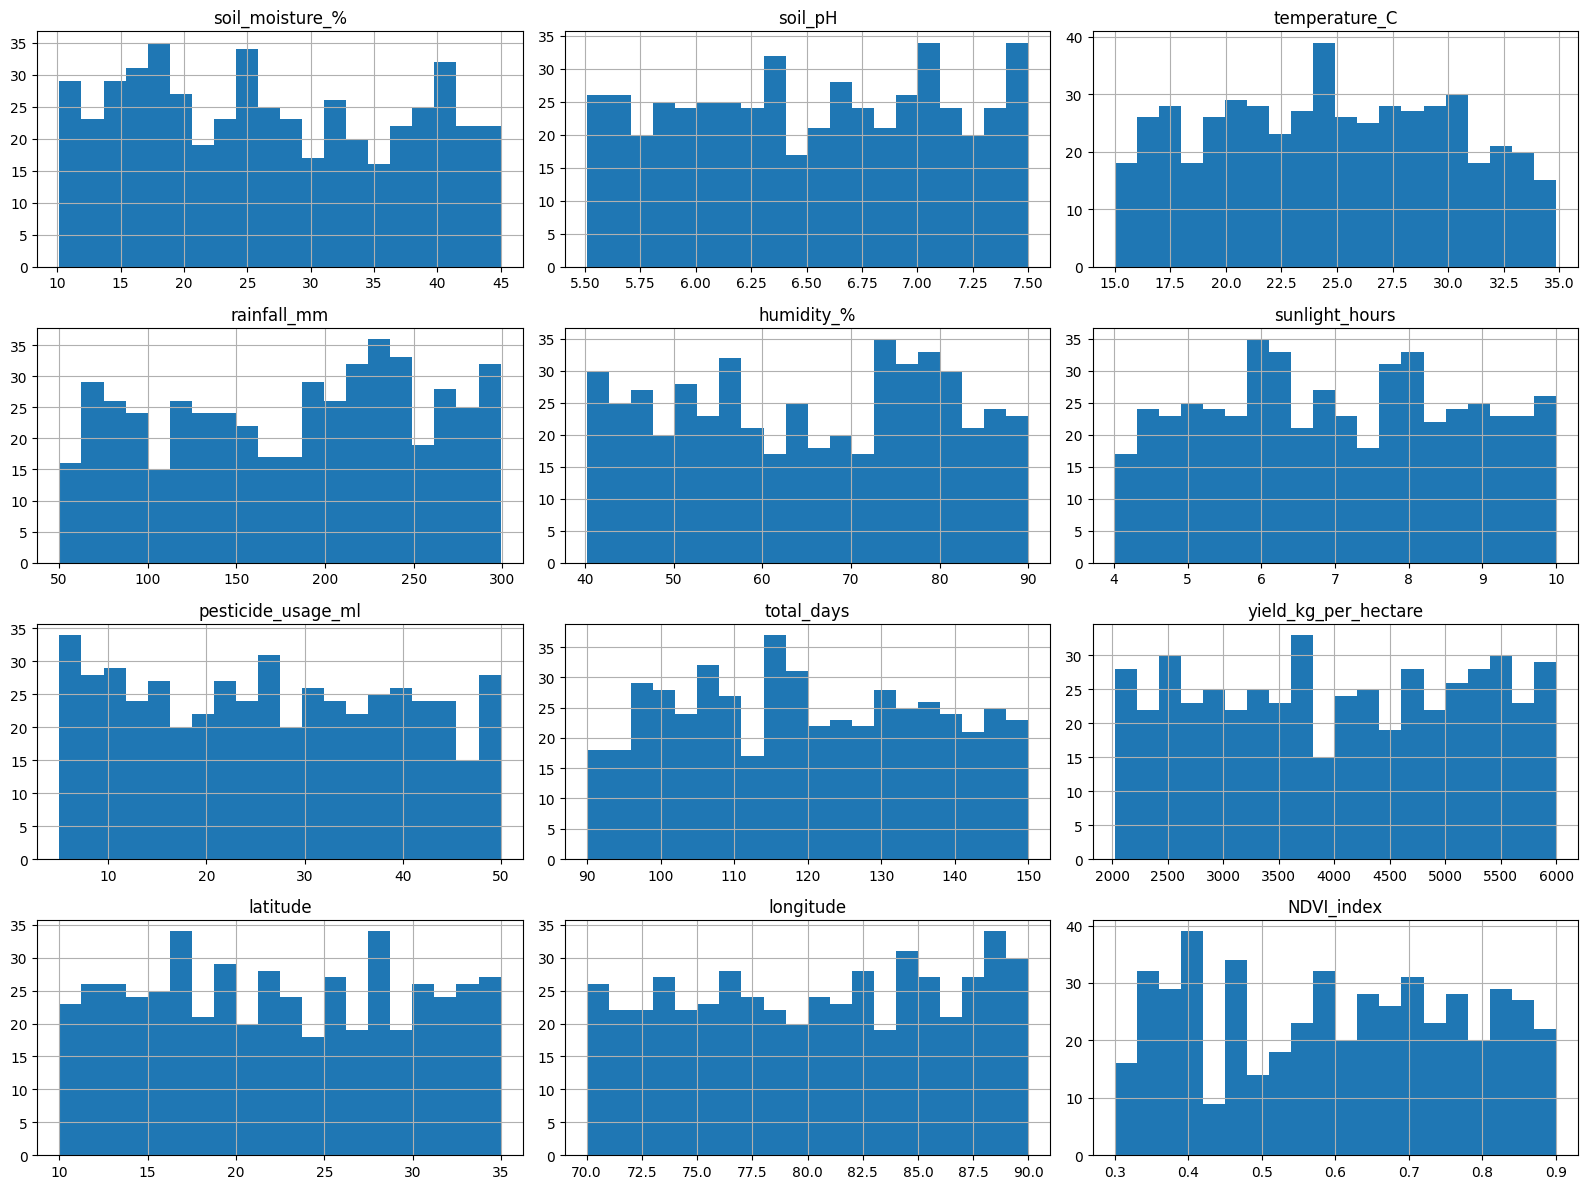

In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()

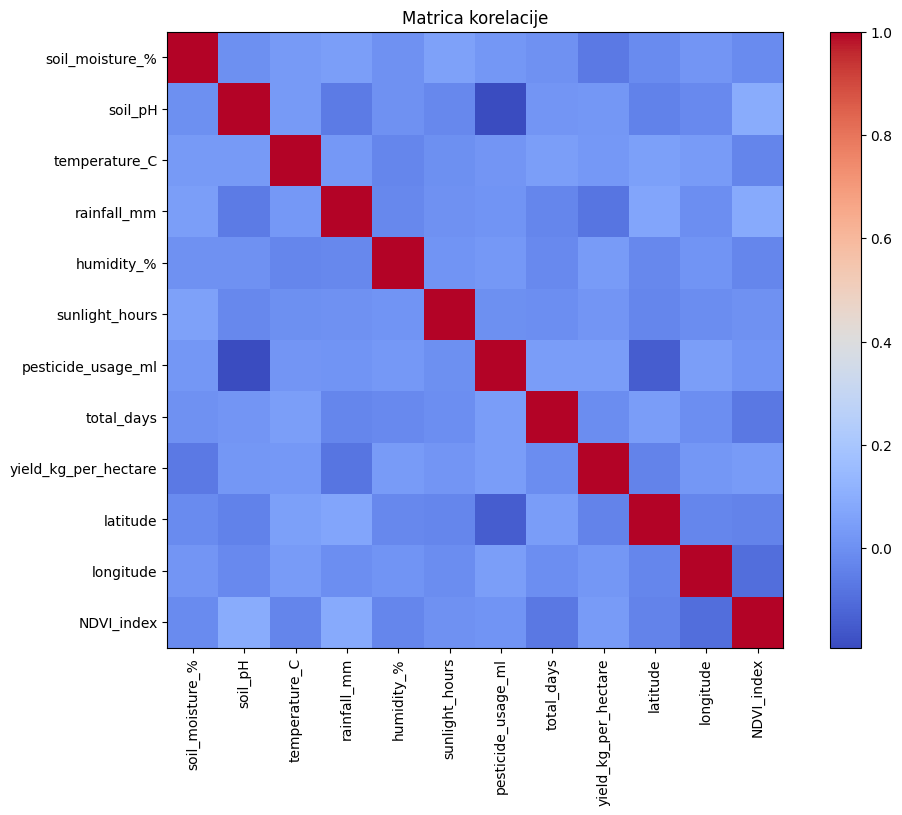

In [7]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Matrica korelacije")
plt.show()

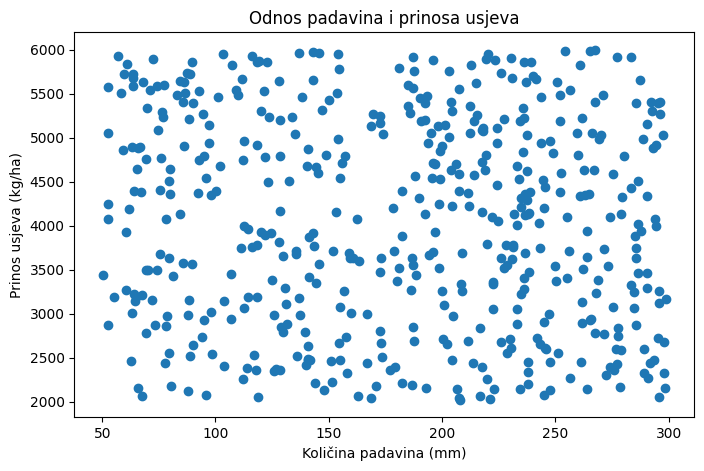

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df["rainfall_mm"], df["yield_kg_per_hectare"])
plt.xlabel("Količina padavina (mm)")
plt.ylabel("Prinos usjeva (kg/ha)")
plt.title("Odnos padavina i prinosa usjeva")
plt.show()

#Podjela skupa podataka i razdvajanje atributa

U ovom dijelu projekta izvršena je stratifikovana podjela skupa podataka na trening i test skup pomoću funkcije train_test_split(). Skup podataka podijeljen je tako da 80% podataka bude korišćeno za obuku modela, dok je 20% rezervisano za testiranje performansi modela. Takođe je izvršeno razdvajanje ulaznih atributa (X) i ciljne vrijednosti (y), gdje ciljnu vrijednost predstavlja prinos usjeva po hektaru (yield_kg_per_hectare). Stratifikacija je izvršena na osnovu kategorija prinosa kako bi raspodjela klasa ostala približno ista u trening i test skupu.

In [9]:
from sklearn.model_selection import train_test_split

df["yield_category"] = pd.cut(
    df["yield_kg_per_hectare"],
    bins=3,
    labels=["nizak", "srednji", "visok"]
)

train_set, test_set = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["yield_category"]
)

train_set.shape, test_set.shape

((400, 23), (100, 23))

In [10]:
X_train = train_set.drop(["yield_kg_per_hectare", "yield_category"], axis=1)
y_train = train_set["yield_kg_per_hectare"]

X_test = test_set.drop(["yield_kg_per_hectare", "yield_category"], axis=1)
y_test = test_set["yield_kg_per_hectare"]

#Transformacija kategoričkih atributa

U ovom dijelu izvršena je transformacija kategoričkih atributa u numerički oblik korišćenjem One-Hot Encoding metode. Ova transformacija je neophodna jer algoritmi mašinskog učenja ne mogu direktno obrađivati tekstualne vrijednosti. Svaka kategorija pretvorena je u poseban numerički atribut sa vrijednostima 0 ili 1, čime su podaci pripremljeni za obuku modela mašinskog učenja.

In [11]:
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[numeric_features] = num_imputer.fit_transform(X_train[numeric_features])
X_test[numeric_features] = num_imputer.transform(X_test[numeric_features])

X_train[categorical_features] = cat_imputer.fit_transform(X_train[categorical_features])
X_test[categorical_features] = cat_imputer.transform(X_test[categorical_features])

In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

In [13]:
encoded_columns = encoder.get_feature_names_out(categorical_features)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

#Linearna regresija
U ovom dijelu izvršena je obuka modela linearne regresije za predviđanje prinosa usjeva na osnovu poljoprivrednih i klimatskih atributa. Linearna regresija predstavlja jedan od osnovnih regresionih modela mašinskog učenja i koristi se za modelovanje linearne veze između ulaznih atributa i ciljne numeričke vrijednosti.

In [14]:
X_train_final = pd.concat(
    [X_train[numeric_features], X_train_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test[numeric_features], X_test_encoded_df],
    axis=1
)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lin_reg = LinearRegression()

lin_reg.fit(X_train_final, y_train)

y_pred = lin_reg.predict(X_test_final)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
lin_reg = LinearRegression()
rmse_linear = rmse
mae_linear = mae

RMSE: 1446.3738530219414
MAE: 1219.567393216411


#Krive učenja
Krive učenja prikazuju kako se greška modela mijenja u odnosu na broj trening primjera. Na osnovu ovih krivih može se analizirati da li model dobro uči iz podataka ili ima problem sa podučenošću ili preučenošću

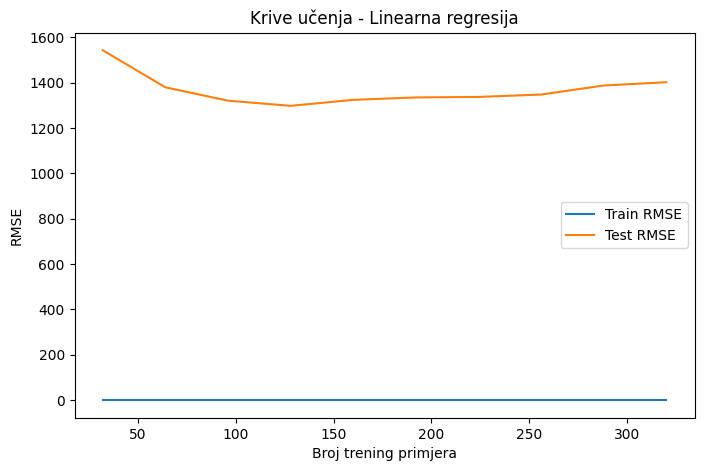

In [16]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X_train_final,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_rmse = -train_scores.mean(axis=1)
test_rmse = -test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, label="Train RMSE")
plt.plot(train_sizes, test_rmse, label="Test RMSE")
plt.xlabel("Broj trening primjera")
plt.ylabel("RMSE")
plt.title("Krive učenja - Linearna regresija")
plt.legend()
plt.show()

#Polinomijalna regresija
U ovom dijelu izvršena je obuka modela polinomijalne regresije. Za razliku od linearne regresije, polinomijalna regresija omogućava modelovanje nelinearnih odnosa između atributa i ciljne vrijednosti. Ovaj model može bolje opisati složenije veze između klimatskih i poljoprivrednih faktora i prinosa usjeva.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train_final, y_train)

y_pred_poly = poly_model.predict(X_test_final)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)

print("RMSE:", rmse_poly)
print("MAE:", mae_poly)

Krive učenja za polinomijalnu regresiju nisu posebno prikazane jer se model zbog velikog broja generisanih atributa izvršava znatno sporije. Za grafički prikaz performansi regresionih modela korišćena je kriva učenja linearne regresije i završno poređenje RMSE vrijednosti svih modela.

#SGD regresor
U ovom dijelu izvršena je obuka SGD regresora. SGD regresor koristi stohastičko gradijentno spuštanje i pogodan je za rad sa većim skupovima podataka, jer model uči postepeno kroz iteracije.

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sgd_reg = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
)

sgd_reg.fit(X_train_final, y_train)

y_pred_sgd = sgd_reg.predict(X_test_final)

rmse_sgd = np.sqrt(mean_squared_error(y_test, y_pred_sgd))
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)

print("RMSE:", rmse_sgd)
print("MAE:", mae_sgd)

#Ridge regresija
U ovom dijelu izvršena je obuka Ridge regresionog modela. Ridge regresija predstavlja regularizovani oblik linearne regresije koji dodaje kaznu na veličinu koeficijenata, čime se smanjuje rizik od preučenosti modela.

In [ ]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1.0)

ridge_reg.fit(X_train_final, y_train)

y_pred_ridge = ridge_reg.predict(X_test_final)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("RMSE:", rmse_ridge)
print("MAE:", mae_ridge)

#Lasso regresija
U ovom dijelu izvršena je obuka Lasso regresionog modela. Lasso regresija koristi regularizaciju kako bi smanjila složenost modela i izvršila selekciju atributa smanjivanjem manje važnih koeficijenata prema nuli.

In [ ]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)

lasso_reg.fit(X_train_final, y_train)

y_pred_lasso = lasso_reg.predict(X_test_final)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print("RMSE:", rmse_lasso)
print("MAE:", mae_lasso)

#Elastic Net regresija


U ovom dijelu izvršena je obuka Elastic Net regresionog modela. Elastic Net kombinuje osobine Ridge i Lasso regresije koristeći oba tipa regularizacije, čime omogućava stabilnije modelovanje i selekciju atributa.

In [ ]:
from sklearn.linear_model import ElasticNet

elastic_reg = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_reg.fit(X_train_final, y_train)

y_pred_elastic = elastic_reg.predict(X_test_final)

rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)

print("RMSE:", rmse_elastic)
print("MAE:", mae_elastic)

#SVM regresor

U ovom dijelu izvršena je obuka SVM regresionih modela sa linearnim, polinomijalnim i RBF jezgrom. SVM regresija pokušava da pronađe funkciju koja što bolje opisuje odnos između ulaznih atributa i ciljne numeričke vrijednosti.

In [ ]:
from sklearn.svm import SVR

svm_linear = make_pipeline(StandardScaler(), SVR(kernel="linear"))
svm_poly = make_pipeline(StandardScaler(), SVR(kernel="poly", degree=2))
svm_rbf = make_pipeline(StandardScaler(), SVR(kernel="rbf"))

svm_models = {
    "SVM linear": svm_linear,
    "SVM poly": svm_poly,
    "SVM RBF": svm_rbf
}

svm_results = {}

for name, model in svm_models.items():

    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    svm_results[name] = rmse

    print(name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print()

#Stablo odlučivanja
U ovom dijelu izvršena je obuka regresionog stabla odlučivanja. Model stabla odlučivanja dijeli podatke na manje grupe na osnovu atributa koji najbolje objašnjavaju ciljnu vrijednost, čime omogućava modelovanje složenih i nelinearnih odnosa između atributa i prinosa usjeva.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)

tree_reg.fit(X_train_final, y_train)

y_pred_tree = tree_reg.predict(X_test_final)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)

print("RMSE:", rmse_tree)
print("MAE:", mae_tree)

#Random Forest regresija
U ovom dijelu izvršena je obuka Random Forest regresionog modela. Random Forest predstavlja ansambl metod koji koristi više stabala odlučivanja i kombinuje njihove rezultate radi poboljšanja tačnosti i stabilnosti modela. Model koristi bagging pristup kako bi smanjio rizik od preučenosti.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_reg.fit(X_train_final, y_train)

y_pred_forest = forest_reg.predict(X_test_final)

rmse_forest = np.sqrt(mean_squared_error(y_test, y_pred_forest))
mae_forest = mean_absolute_error(y_test, y_pred_forest)

print("RMSE:", rmse_forest)
print("MAE:", mae_forest)

#Bagging regresor


U ovom dijelu izvršena je obuka Bagging regresionog modela. Bagging metoda koristi više modela obučenih na različitim podskupovima trening podataka, a konačno predviđanje dobija se kombinovanjem rezultata svih modela radi poboljšanja stabilnosti i tačnosti.


In [ ]:
from sklearn.ensemble import BaggingRegressor

bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

bagging_reg.fit(X_train_final, y_train)

y_pred_bag = bagging_reg.predict(X_test_final)

rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bag))
mae_bag = mean_absolute_error(y_test, y_pred_bag)

print("RMSE:", rmse_bag)
print("MAE:", mae_bag)

#Pasting regresor

Pasting metoda funkcioniše slično bagging pristupu, ali se podskupovi podataka formiraju bez ponavljanja uzoraka. Cilj metode je povećanje stabilnosti i smanjenje varijanse modela.


In [ ]:
pasting_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    bootstrap=False,
    random_state=42
)

pasting_reg.fit(X_train_final, y_train)

y_pred_past = pasting_reg.predict(X_test_final)

rmse_past = np.sqrt(mean_squared_error(y_test, y_pred_past))
mae_past = mean_absolute_error(y_test, y_pred_past)

print("RMSE:", rmse_past)
print("MAE:", mae_past)

#**Klasifikacija**

#Priprema podataka za klasifikaciju
U ovom dijelu pripremljeni su podaci za klasifikacione modele mašinskog učenja. Kao ciljna vrijednost korišćena je kategorička etiketa prinosa usjeva (yield_category), koja dijeli prinose na nizak, srednji i visok nivo

In [ ]:
X_class = df.drop(["yield_kg_per_hectare", "yield_category"], axis=1)
y_class = df["yield_category"]

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Obrada missing values i kategorija

In [ ]:
numeric_features_c = X_train_c.select_dtypes(include=["int64", "float64"]).columns
categorical_features_c = X_train_c.select_dtypes(include=["object"]).columns

num_imputer_c = SimpleImputer(strategy="median")
cat_imputer_c = SimpleImputer(strategy="most_frequent")

X_train_c[numeric_features_c] = num_imputer_c.fit_transform(X_train_c[numeric_features_c])
X_test_c[numeric_features_c] = num_imputer_c.transform(X_test_c[numeric_features_c])

X_train_c[categorical_features_c] = cat_imputer_c.fit_transform(X_train_c[categorical_features_c])
X_test_c[categorical_features_c] = cat_imputer_c.transform(X_test_c[categorical_features_c])

encoder_c = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_encoded_c = encoder_c.fit_transform(X_train_c[categorical_features_c])
X_test_encoded_c = encoder_c.transform(X_test_c[categorical_features_c])

encoded_columns_c = encoder_c.get_feature_names_out(categorical_features_c)

X_train_encoded_df_c = pd.DataFrame(
    X_train_encoded_c,
    columns=encoded_columns_c,
    index=X_train_c.index
)

X_test_encoded_df_c = pd.DataFrame(
    X_test_encoded_c,
    columns=encoded_columns_c,
    index=X_test_c.index
)

X_train_final_c = pd.concat(
    [X_train_c[numeric_features_c], X_train_encoded_df_c],
    axis=1
)

X_test_final_c = pd.concat(
    [X_test_c[numeric_features_c], X_test_encoded_df_c],
    axis=1
)

#SGD klasifikator
U ovom dijelu izvršena je obuka SGD klasifikatora za klasifikaciju prinosa usjeva na nizak, srednji i visok nivo. SGD klasifikator koristi stohastičko gradijentno spuštanje i pogodan je za rad sa većim skupovima podataka.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(random_state=42)
)

sgd_clf.fit(X_train_final_c, y_train_c)

y_pred_sgd_c = sgd_clf.predict(X_test_final_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_sgd_c))
print("Precision:", precision_score(y_test_c, y_pred_sgd_c, average="weighted"))
print("Recall:", recall_score(y_test_c, y_pred_sgd_c, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_sgd_c, average="weighted"))

print(confusion_matrix(y_test_c, y_pred_sgd_c))

#Logistička regresija

U ovom dijelu izvršena je obuka logističke regresije za višeklasnu klasifikaciju prinosa usjeva. Model pokušava da klasifikuje prinos u jednu od tri klase: nizak, srednji ili visok.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

log_reg.fit(X_train_final_c, y_train_c)

y_pred_log = log_reg.predict(X_test_final_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_log))
print("Precision:", precision_score(y_test_c, y_pred_log, average="weighted"))
print("Recall:", recall_score(y_test_c, y_pred_log, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_log, average="weighted"))

print(confusion_matrix(y_test_c, y_pred_log))

#SVM klasifikator

U ovom dijelu izvršena je obuka SVM klasifikatora sa linearnim, polinomijalnim i RBF jezgrom. Cilj modela je klasifikacija prinosa usjeva u tri klase: nizak, srednji i visok prinos.

In [ ]:
from sklearn.svm import SVC

svm_linear_c = make_pipeline(StandardScaler(), SVC(kernel="linear", random_state=42))
svm_poly_c = make_pipeline(StandardScaler(), SVC(kernel="poly", degree=2, random_state=42))
svm_rbf_c = make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=42))

svm_class_models = {
    "SVM linear": svm_linear_c,
    "SVM poly": svm_poly_c,
    "SVM RBF": svm_rbf_c
}

for name, model in svm_class_models.items():
    model.fit(X_train_final_c, y_train_c)
    y_pred = model.predict(X_test_final_c)

    print(name)
    print("Accuracy:", accuracy_score(y_test_c, y_pred))
    print("Precision:", precision_score(y_test_c, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test_c, y_pred, average="weighted"))
    print("F1:", f1_score(y_test_c, y_pred, average="weighted"))
    print(confusion_matrix(y_test_c, y_pred))
    print()

#Stablo odlučivanja — klasifikacija
U ovom dijelu izvršena je obuka klasifikacionog stabla odlučivanja. Model pokušava da klasifikuje prinos usjeva u tri kategorije: nizak, srednji i visok prinos

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)

tree_clf.fit(X_train_final_c, y_train_c)

y_pred_tree_c = tree_clf.predict(X_test_final_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_tree_c))
print("Precision:", precision_score(y_test_c, y_pred_tree_c, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_tree_c, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_tree_c, average="weighted"))

print(confusion_matrix(y_test_c, y_pred_tree_c))

#Random Forest klasifikator

U ovom dijelu izvršena je obuka Random Forest klasifikatora. Ovaj model koristi više stabala odlučivanja i kombinuje njihova predviđanja kako bi se dobila stabilnija i tačnija klasifikacija prinosa usjeva.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_clf.fit(X_train_final_c, y_train_c)

y_pred_forest_c = forest_clf.predict(X_test_final_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_forest_c))
print("Precision:", precision_score(y_test_c, y_pred_forest_c, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_forest_c, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_forest_c, average="weighted"))

print(confusion_matrix(y_test_c, y_pred_forest_c))

#Bagging i Pasting klasifikatori

U ovom dijelu izvršena je obuka Bagging i Pasting klasifikatora.
 Obje metode predstavljaju ansambl pristupe koji koriste više stabala odlučivanja radi  poboljšanja tačnosti i stabilnosti klasifikacije. Bagging metoda formira podskupove podataka sa ponavljanjem uzoraka (bootstrap), dok Pasting koristi podskupove bez ponavljanja. Kombinovanjem predviđanja više modela smanjuje se varijansa i rizik od preučenosti, čime se postižu stabilniji rezultati klasifikacije prinosa usjeva.

In [ ]:
from sklearn.ensemble import BaggingClassifier

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

bagging_clf.fit(X_train_final_c, y_train_c)
y_pred_bag_c = bagging_clf.predict(X_test_final_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_bag_c))
print("Precision:", precision_score(y_test_c, y_pred_bag_c, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_bag_c, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_bag_c, average="weighted"))
print(confusion_matrix(y_test_c, y_pred_bag_c))

In [ ]:
pasting_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    bootstrap=False,
    random_state=42
)

pasting_clf.fit(X_train_final_c, y_train_c)
y_pred_past_c = pasting_clf.predict(X_test_final_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_past_c))
print("Precision:", precision_score(y_test_c, y_pred_past_c, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test_c, y_pred_past_c, average="weighted"))
print("F1:", f1_score(y_test_c, y_pred_past_c, average="weighted"))
print(confusion_matrix(y_test_c, y_pred_past_c))

#Grafičko poređenje modela

U ovom dijelu izvršeno je grafičko poređenje performansi regresionih modela korišćenjem RMSE metrike. Manja vrijednost RMSE ukazuje na bolju preciznost modela.

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Linear",
    "Polynomial",
    "SGD",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "SVM Linear",
    "SVM Poly",
    "SVM RBF",
    "Decision Tree",
    "RandomForest",
    "Bagging",
    "Pasting"
]

rmse_values = [
    rmse_linear,
    rmse_poly,
    rmse_sgd,
    rmse_ridge,
    rmse_lasso,
    rmse_elastic,
    svm_results["SVM linear"],
    svm_results["SVM poly"],
    svm_results["SVM RBF"],
    rmse_tree,
    rmse_forest,
    rmse_bag,
    rmse_past
]

plt.figure(figsize=(14,5))

plt.bar(models, rmse_values)

plt.xlabel("Modeli")
plt.ylabel("RMSE")
plt.title("Poređenje regresionih modela")

plt.xticks(rotation=20)

plt.show()

#Grafičko poređenje klasifikacionih modela

U ovom dijelu izvršeno je poređenje klasifikacionih modela korišćenjem accuracy metrike.

In [ ]:
class_models = [
    "SGD",
    "Logistic",
    "SVM Linear",
    "SVM Poly",
    "SVM RBF",
    "Decision Tree",
    "RandomForest",
    "Bagging",
    "Pasting"
]

accuracy_values = [
    0.29,
    0.31,
    0.32,
    0.35,
    0.32,
    0.33,
    0.34,
    0.35,
    0.33
]

plt.figure(figsize=(12,5))

plt.bar(class_models, accuracy_values)

plt.xlabel("Modeli")
plt.ylabel("Accuracy")
plt.title("Poređenje klasifikacionih modela")

plt.xticks(rotation=15)

plt.show()

# ROC kriva za klasifikaciju

U ovom dijelu prikazana je ROC kriva za Random Forest klasifikator. ROC kriva prikazuje sposobnost modela da razlikuje klase prinosa usjeva, a AUC vrijednost pokazuje kvalitet klasifikacije.

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test_c, classes=["nizak", "srednji", "visok"])

y_score = forest_clf.predict_proba(X_test_final_c)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

colors = ["blue", "green", "red"]
labels = ["Nizak", "Srednji", "Visok"]

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC kriva - Random Forest klasifikator")
plt.legend()

plt.show()